In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
import os
os.chdir("/Users/divya/Downloads/food_intelligence")
print(os.getcwd())

/Users/divya/Downloads/food_intelligence


In [3]:
files = list(Path("data/cleaned").glob("silver_*.parquet"))
latest = max(files, key=lambda f: f.stat().st_mtime)
df = pd.read_parquet(latest)
print(df.shape)

(307645, 12)


In [4]:
print(f'df.info(): {df.info()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   YEAR              307645 non-null  int64         
 1   MONTH             307645 non-null  int64         
 2   SUPPLIER          307645 non-null  object        
 3   ITEM CODE         307645 non-null  object        
 4   ITEM DESCRIPTION  307645 non-null  object        
 5   ITEM TYPE         307644 non-null  object        
 6   RETAIL SALES      307642 non-null  float64       
 7   RETAIL TRANSFERS  307645 non-null  float64       
 8   WAREHOUSE SALES   307645 non-null  float64       
 9   _ingested_at      307645 non-null  object        
 10  _source_file      307645 non-null  object        
 11  DATE              307645 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(6)
memory usage: 28.2+ MB
df.info(): None


In [5]:
import dataframe_image as dfi
desc = df.describe()
# Save describe() output directly as a PNG
dfi.export(
    desc, 
    filename="eda_describe_simple.png", 
    table_conversion="matplotlib",  # Use matplotlib for rendering
    dpi=300  # High resolution for crisp text
)



/Users/divya/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [6]:
print(f'df.head(): {df.head()}')


df.head():    YEAR  MONTH                           SUPPLIER ITEM CODE  \
0  2020      1  Republic National Distributing Co    100009   
1  2020      1                          Pwswn Inc    100024   
2  2020      1            Reliable Churchill Lllp      1001   
3  2020      1          Lanterna Distributors Inc    100145   
4  2020      1               Dionysos Imports Inc    100293   

                      ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
0                  Bootleg Red - 750Ml      Wine          0.00   
1            Moment De Plaisir - 750Ml      Wine          0.00   
2  S Smith Organic Pear Cider - 18.7Oz      Beer          0.00   
3        Schlink Haus Kabinett - 750Ml      Wine          0.00   
4       Santorini Gavala White - 750Ml      Wine          0.82   

   RETAIL TRANSFERS  WAREHOUSE SALES                _ingested_at  \
0               0.0              2.0  2026-06-16T12:16:29.951241   
1               1.0              4.0  2026-06-16T12:16:29.951241   
2        

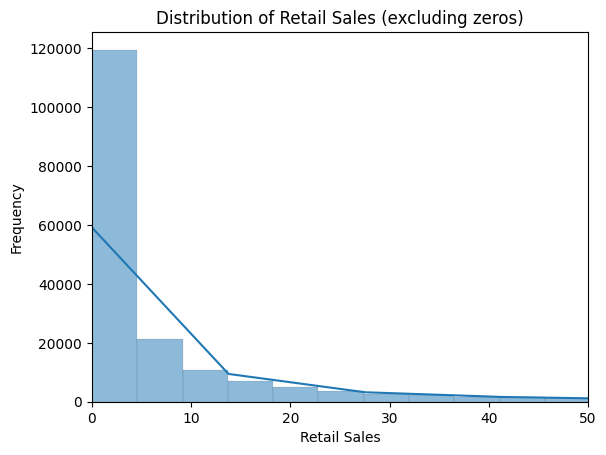

In [7]:
# filter out zeros first to see the real distribution
retail_nonzero = df[df['RETAIL SALES'] > 0]['RETAIL SALES']

sns.histplot(retail_nonzero, bins=600, kde=True)
plt.xlim(0, 50)
plt.title('Distribution of Retail Sales (excluding zeros)')
plt.xlabel('Retail Sales')
plt.ylabel('Frequency')
plt.show()

This food distributor's retail business
is built on massive volume of tiny sales.

The average retail transaction is under $3.
A manager looking at "average retail sale = $7"
from df.describe() would be misled —
because the mean is pulled up by rare large sales.

The REAL typical sale is under $3.
That is what the median and this chart confirm.

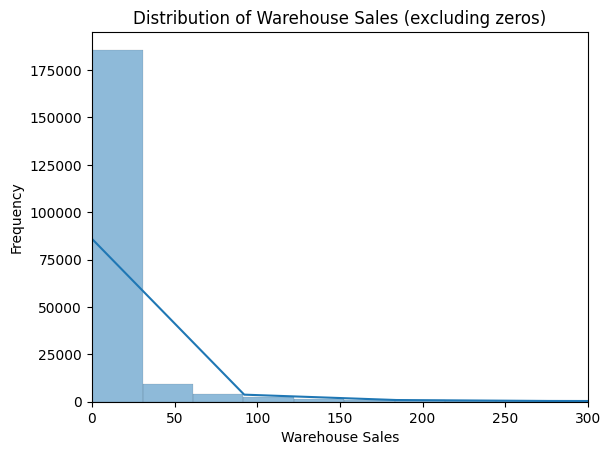

In [8]:
#What does warehouse sales look like?
sns.histplot(df[df['WAREHOUSE SALES'] > 0]['WAREHOUSE SALES'], bins=600, kde=True)
plt.xlim(0, 300)
plt.title('Distribution of Warehouse Sales (excluding zeros)')
plt.xlabel('Warehouse Sales')
plt.ylabel('Frequency')
plt.show()

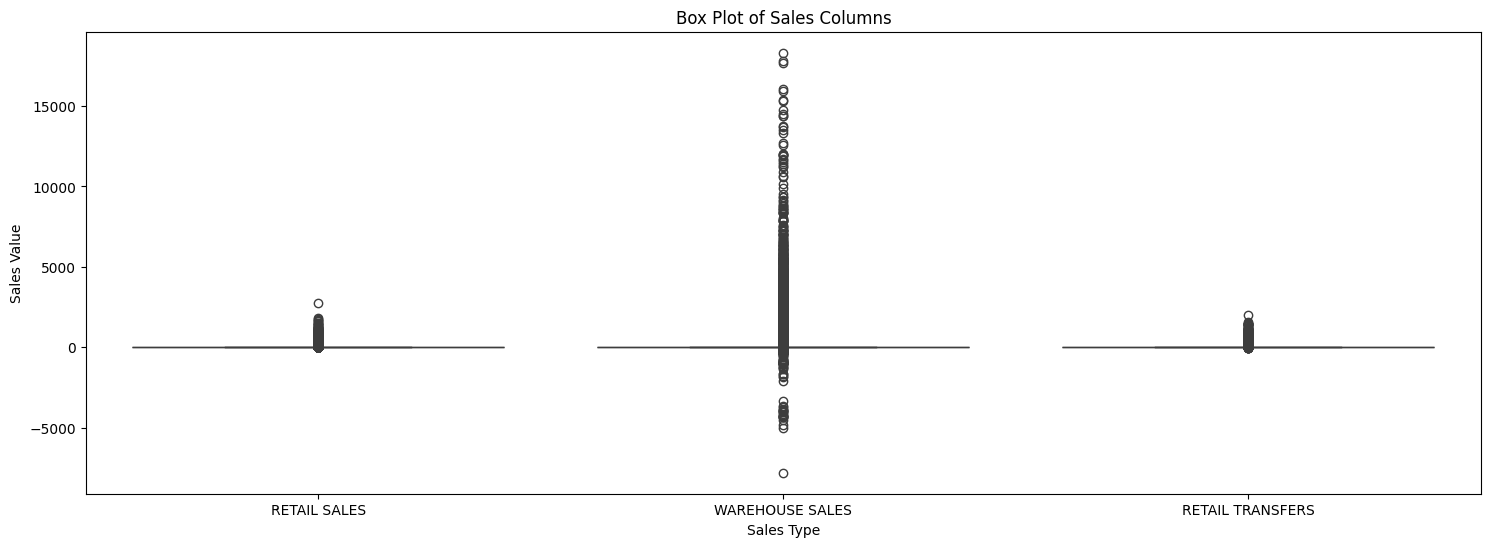

In [9]:
# create a box plot comparing all three sales columns

# use plt.subplots to create 3 side by side charts
plt.figure(figsize=(18, 6))
sns.boxplot(data=df[['RETAIL SALES', 'WAREHOUSE SALES', 'RETAIL TRANSFERS']])
plt.title('Box Plot of Sales Columns')
plt.xlabel('Sales Type')
plt.ylabel('Sales Value')
plt.show()
# one box plot per column
# add title and labels
# plt.show()

In [10]:
Q1 = df['RETAIL SALES'].quantile(0.25)
Q3 = df['RETAIL SALES'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Retail Sales - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Retail Sales - Q1: 0.0, Q3: 3.2675, IQR: 3.2675, Lower Bound: -4.90125, Upper Bound: 8.16875


In [11]:
Q1  = df['WAREHOUSE SALES'].quantile(0.25)
Q3  = df['WAREHOUSE SALES'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - (1.5 * IQR)
upper_fence = Q3 + (1.5 * IQR)

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower fence: {lower_fence}")
print(f"Upper fence: {upper_fence}")
print(df['WAREHOUSE SALES'].max())
print(df['WAREHOUSE SALES'].min())



Q1: 0.0
Q3: 5.0
IQR: 5.0
Lower fence: -7.5
Upper fence: 12.5
18317.0
-7800.0


In [12]:
# find the highest warehouse sale
print("HIGHEST WAREHOUSE SALE:")
print(df[df['WAREHOUSE SALES'] == df['WAREHOUSE SALES'].max()])

print("\nLOWEST WAREHOUSE SALE:")
print(df[df['WAREHOUSE SALES'] == df['WAREHOUSE SALES'].min()])


HIGHEST WAREHOUSE SALE:
       YEAR  MONTH       SUPPLIER ITEM CODE              ITEM DESCRIPTION  \
13281  2020      7  Crown Imports     23445  Corona Extra Loose Nr - 12Oz   

      ITEM TYPE  RETAIL SALES  RETAIL TRANSFERS  WAREHOUSE SALES  \
13281      Beer        1174.0            1041.0          18317.0   

                     _ingested_at                    _source_file       DATE  
13281  2026-06-16T12:16:29.951241  Warehouse_and_Retail_Sales.csv 2020-07-01  

LOWEST WAREHOUSE SALE:
        YEAR  MONTH SUPPLIER ITEM CODE          ITEM DESCRIPTION ITEM TYPE  \
254069  2019      8  Unknown       600  Istore Training Overview       Ref   

        RETAIL SALES  RETAIL TRANSFERS  WAREHOUSE SALES  \
254069           0.0               0.0          -7800.0   

                      _ingested_at                    _source_file       DATE  
254069  2026-06-16T12:16:29.951241  Warehouse_and_Retail_Sales.csv 2019-08-01  


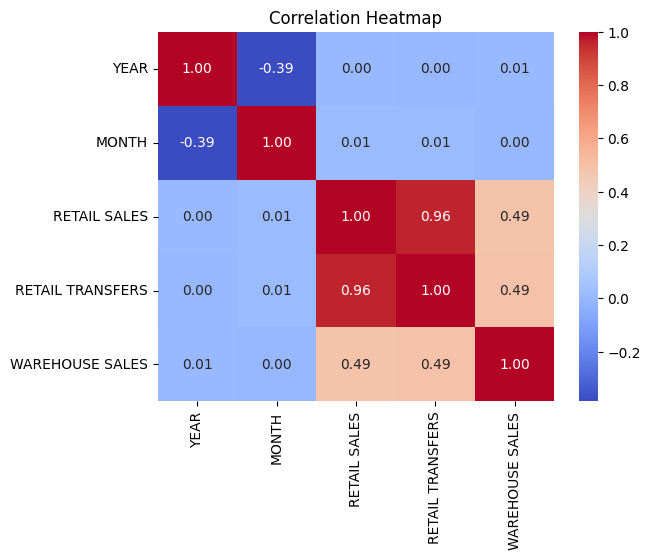

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


**Business meaning**:


When retail sells more
transfers between locations increase too
Makes complete sense —

high demand store pulls stock
from other locations to fulfil orders

When warehouse ships more
retail tends to sell more too

But not always —
warehouse can bulk ship to storage
without immediate retail impact


Is the business growing or shrinking?
Which months are always high?
Which months are always low?
Did COVID in early 2020 impact sales?

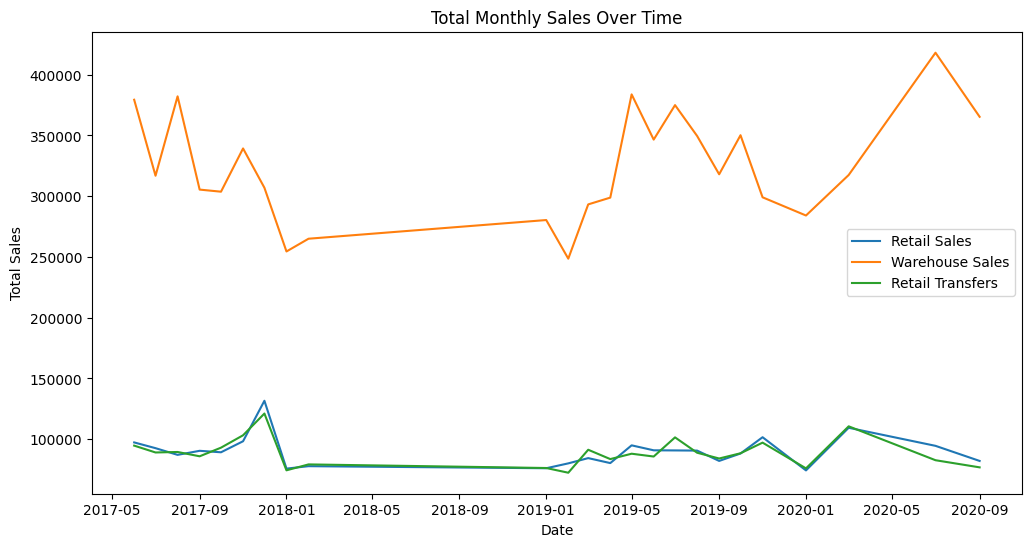

In [14]:
#Total monthly sales over time line chart shows the overall trend
df['DATE'] = pd.to_datetime(df['DATE'])
monthly_sales = df.groupby('DATE')[['RETAIL SALES', 'WAREHOUSE SALES', 'RETAIL TRANSFERS']].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='DATE', y='RETAIL SALES', label='Retail Sales')
sns.lineplot(data=monthly_sales, x='DATE', y='WAREHOUSE SALES', label='Warehouse Sales')
sns.lineplot(data=monthly_sales, x='DATE', y='RETAIL TRANSFERS', label='Retail Transfers')
plt.title('Total Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.show()


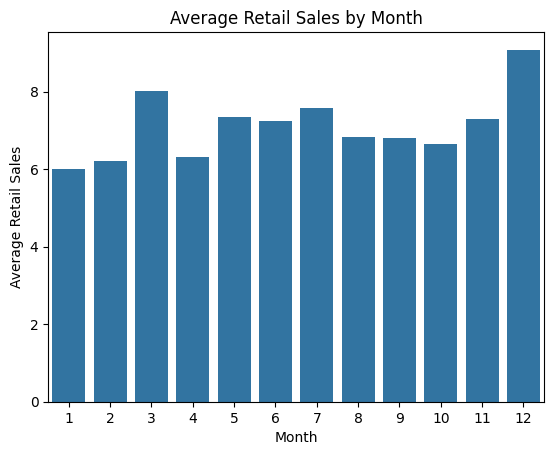

In [15]:
# group by MONTH
df['MONTH']= df['DATE'].dt.month
# calculate mean sales per month
df_monthly = df.groupby('MONTH')[['RETAIL SALES']].mean().reset_index()
# plot as bar chart
sns.barplot(data=df_monthly, x= 'MONTH',y='RETAIL SALES')
plt.title('Average Retail Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Retail Sales')
plt.show()
# this shows seasonal patterns

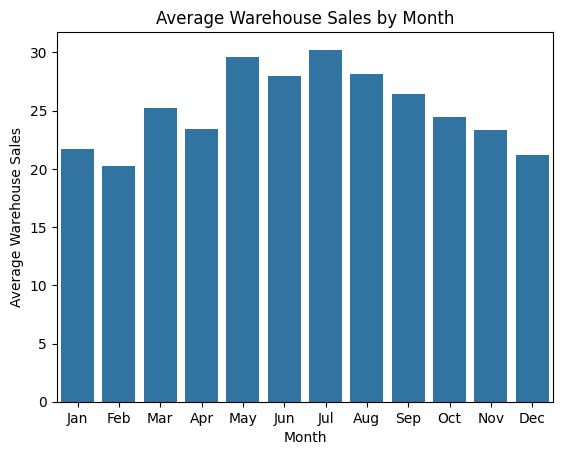

In [16]:
# group by MONTH
df['MONTH']= df['DATE'].dt.month
# calculate mean sales per month
df_monthly = df.groupby('MONTH')[['WAREHOUSE SALES']].mean().reset_index()
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
df_monthly['MONTH'] = df_monthly['MONTH'].map(month_names)
# plot as bar chart
sns.barplot(data=df_monthly, x= 'MONTH',y='WAREHOUSE SALES')
plt.title('Average Warehouse Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Warehouse Sales')
plt.show()
# this shows seasonal patterns

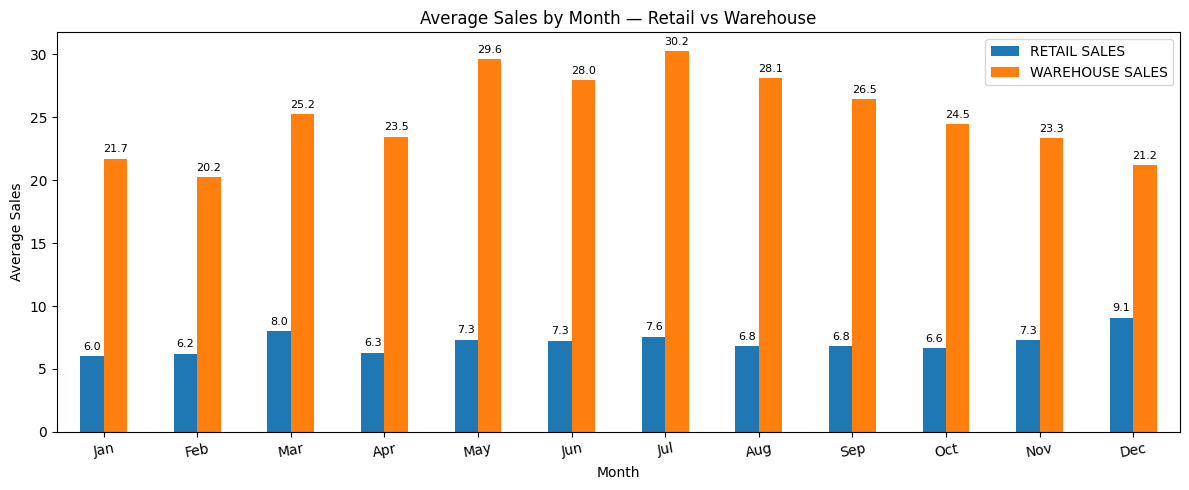

In [17]:
monthly_avg = df.groupby('MONTH')[['RETAIL SALES', 'WAREHOUSE SALES']].mean()

# rename index to month names
monthly_avg.index = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

# plot grouped bar chart
monthly_avg.plot(kind='bar', figsize=(12, 5))
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', fontsize=8, padding=3)

plt.title('Average Sales by Month — Retail vs Warehouse')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [18]:
# do the same suppliers order more in July?
df.groupby(['SUPPLIER', 'MONTH'])['WAREHOUSE SALES'].mean()

SUPPLIER    MONTH
8 Vini Inc  1        0.0
            6        0.0
            7        0.0
            8        0.0
            9        0.0
                    ... 
Zurena Llc  8        0.0
            9        0.0
            10       0.0
            11       0.0
            12       0.0
Name: WAREHOUSE SALES, Length: 3894, dtype: float64

In [19]:
top_suppliers = df.groupby('SUPPLIER')['WAREHOUSE SALES'].sum()
top_suppliers = top_suppliers.sort_values(ascending=False).head(10)
print(top_suppliers)

SUPPLIER
Crown Imports               1651871.51
Miller Brewing Company      1425428.71
Anheuser Busch Inc          1331170.84
Heineken Usa                 829796.46
E & J Gallo Winery           197463.78
Boston Beer Corporation      191592.89
Diageo North America Inc     170564.63
Yuengling Brewery            134147.86
Flying Dog Brewery Lllp      128292.49
Constellation Brands         119399.51
Name: WAREHOUSE SALES, dtype: float64


/var/folders/gj/j8_flj2n03s4x4_tyhl_blwr0000gn/T/ipykernel_3757/2278702289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_suppliers, x='WAREHOUSE SALES', y='SUPPLIER', palette='viridis')


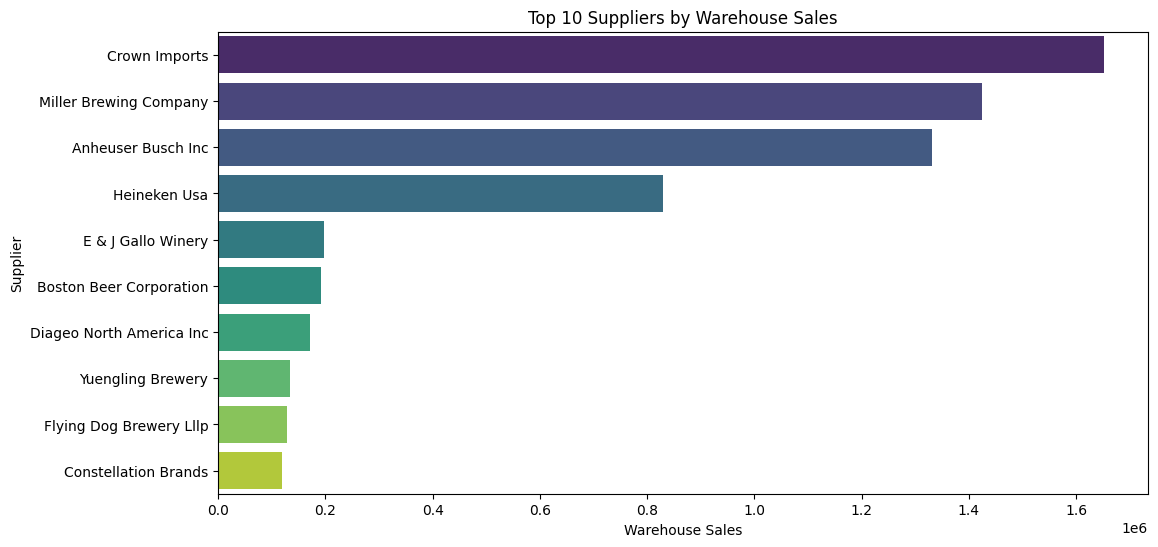

In [20]:
# horizontal bar chart
df_top_suppliers = top_suppliers.reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_suppliers, x='WAREHOUSE SALES', y='SUPPLIER', palette='viridis')
plt.title('Top 10 Suppliers by Warehouse Sales')
plt.xlabel('Warehouse Sales')
plt.ylabel('Supplier')
plt.show()
# top 10 suppliers by warehouse sales
# sorted largest to smallest
# numbers on the bars


/var/folders/gj/j8_flj2n03s4x4_tyhl_blwr0000gn/T/ipykernel_3757/3478246417.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=item_type.reset_index(), x='WAREHOUSE SALES', y='ITEM TYPE', palette='magma')


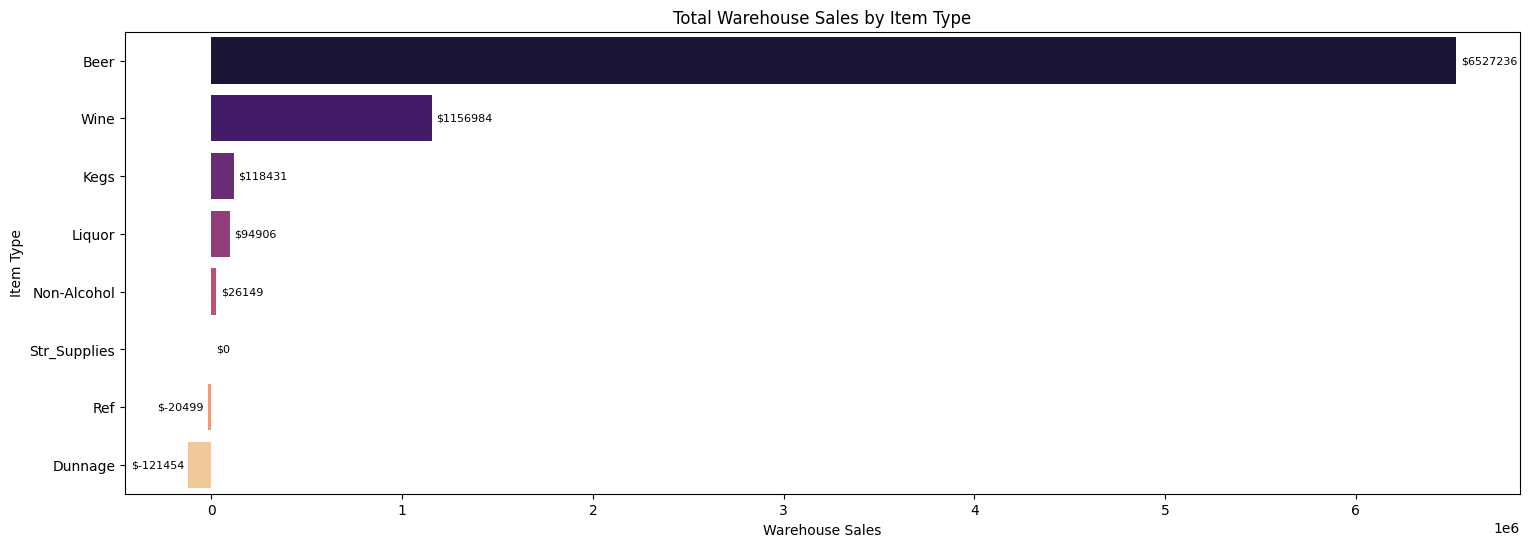

In [21]:
item_type =df.groupby('ITEM TYPE')['WAREHOUSE SALES'].sum().sort_values(ascending=False)
plt.figure(figsize=(18, 6))
ax=sns.barplot(data=item_type.reset_index(), x='WAREHOUSE SALES', y='ITEM TYPE', palette='magma')
for container in ax.containers:
    ax.bar_label(container, fmt='$%d', fontsize=8, padding=3)
plt.title('Total Warehouse Sales by Item Type')

plt.xlabel('Warehouse Sales')
plt.ylabel('Item Type')
plt.show()

"Beer dominates this business completely —
accounting for over 80% of all warehouse revenue
at $6.5M over the dataset period.


Wine is a meaningful secondary category at $1.2M
but operates at a fraction of beer's scale.


Ref and Dunnage categories show negative totals —
confirming these are accounting adjustments
not real product movements.


Any forecasting model should treat Beer and Wine
as the primary revenue drivers and exclude
Ref, Dunnage, and Str_Supplies from modelling."

In [26]:
import pandas as pd
from pathlib import Path
import glob

# load gold file
files = glob.glob("data/processed/gold_*.parquet")
latest = max(files)
df = pd.read_parquet(latest)



# investigate None item type
none_rows = df[df['ITEM TYPE'].isna() | (df['ITEM TYPE'] == 'None')]
print(f"None rows count: {len(none_rows)}")
print(none_rows[['SUPPLIER', 'ITEM TYPE', 'ITEM DESCRIPTION', 'WAREHOUSE SALES', 'RETAIL SALES', 'DATE']].head(20))

None rows count: 1
                                SUPPLIER ITEM TYPE  \
95345  Republic National Distributing Co      None   

                               ITEM DESCRIPTION  WAREHOUSE SALES  \
95345  Fontanafredda Barolo Silver Label 750 Ml              1.0   

       RETAIL SALES       DATE  
95345           0.0 2017-10-01  


In [24]:
# Fill missing ITEM TYPE based on item description
df.loc[df['ITEM TYPE'].isna(), 'ITEM TYPE'] = 'Wine'


In [23]:
#